# ProfileMLP V1 — test notebook

Small end-to-end test of `MLP_regreesionV1.py`'s `ProfileMLP` on a toy directed-evolution
library, mirroring the Ridge tests in `../DE_loopV1.ipynb` (see its "smallN" section) so the
two are directly comparable on the same protocol.

Scope reminder (see the header of `MLP_regreesionV1.py`): V1 only predicts the **profile**
(F) model from single-site one-hot features — no pairwise (J) terms yet.


## 0. Setup

In [ ]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# GB10 has unified CPU/GPU memory: JAX's default (preallocate ~75% of total platform
# memory on first use) leaves too little headroom once torch also claims CUDA memory
# in this same process. Must run before the first `import jax` anywhere (including
# transitively via sequence_classesV1 / RegressionV1 / MLP_regreesionV1), hence this
# cell has to stay first.


In [ ]:
import sys, os

# This notebook lives in Modelization_V1/MLP regression/, one level below
# sequence_classesV1.py / analysisV1.py / RegressionV1.py -- add the parent dir so
# MLP_regreesionV1.py's own `from sequence_classesV1 import *` etc. resolve too.
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))


In [ ]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 2.1


In [ ]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 2.3


In [ ]:
import RegressionV1 as reg
print(reg.message)


file regression 1.3


In [ ]:
import MLP_regreesionV1 as mlp
print(mlp.__file__)
print(mlp.message)


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/MLP regression/MLP_regreesionV1.py
file MLP regression 1.0


In [ ]:
import jax
import numpy as np
import matplotlib.pyplot as plt
import torch

from sequence_classesV1 import ProtocolV2, initialize_random_weights
from analysisV1 import plot_teacher_vs_student, pearson

print(f"jax backend  : {jax.default_backend()} -- devices: {jax.devices()}")
print(f"torch device : {mlp.DEVICE} "
      f"({torch.cuda.get_device_name(0) if mlp.DEVICE.type == 'cuda' else 'CPU'})")


jax backend  : gpu -- devices: [CudaDevice(id=0)]
torch device : cuda (NVIDIA GB10)


## 1. Toy library

Same shape as `DE_loopV1.ipynb`'s "smallN" Ridge test (`N=2000`, `n_rounds=1`), so
`ProfileMLP` and Ridge are being compared on the exact same protocol below.


In [ ]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20000
sequences = jax.random.randint(k_seq, shape=(N, 7), minval=0, maxval=20)
F_viab, F_sel, J_viab, J_sel = initialize_random_weights(key)

protocol = ProtocolV2(
    N0=100_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape)


protocol.sequence shape: (2000000, 7)


## 2. Train ProfileMLP on NGS-observable reads

`recover_profile_from_NGS` builds the pooled multi-round log-ratio dataset from
`protocol`'s observable NGS reads only (`lambda0p`/`lambda2p`/`lambda3p`, same as
`RegressionV1.recover_weights_from_NGS`), then trains one `ProfileMLP` per step
(viability, selectivity).


In [ ]:
F_viab_hat, F_sel_hat, info = mlp.recover_profile_from_NGS(
    protocol, n_rounds=1,
    mlp_kwargs=dict(epochs=300, patience=20, batch_size=256),
)

print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")


torch device: cuda (NVIDIA GB10)


Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.32s/it]


Viability   dataset: 1986466 pairs -> 1688497 train / 297969 val
Selectivity dataset: 201312 pairs -> 171116 train / 30196 val


Training ProfileMLP:   8%|▊         | 23/300 [08:11<1:38:37, 21.36s/it]


Early stopping at epoch 23 (best val MSE=2.6101)


Training ProfileMLP:  15%|█▍        | 44/300 [01:35<09:16,  2.17s/it]

Early stopping at epoch 44 (best val MSE=0.4604)
n_obs_viab = 1986466   n_obs_sel = 201312


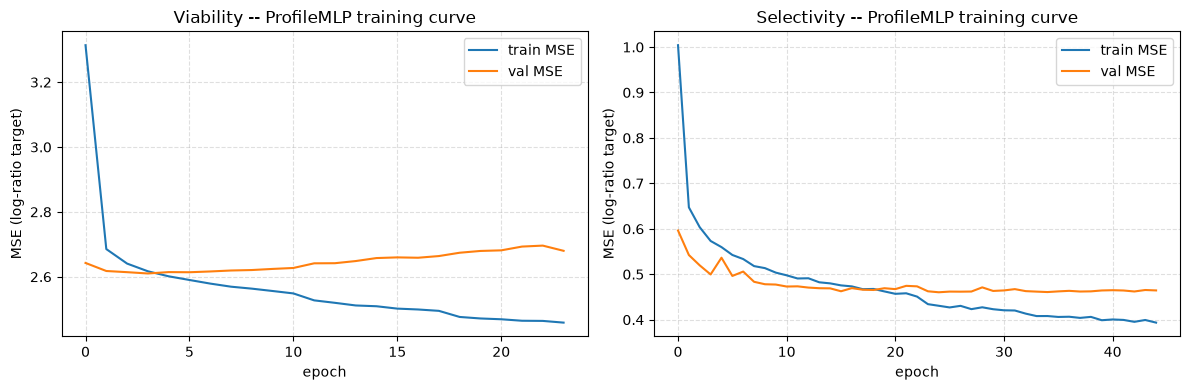

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, hist in [(axes[0], "Viability", info["history_viab"]),
                        (axes[1], "Selectivity", info["history_sel"])]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (log-ratio target)")
    ax.set_title(f"{name} -- ProfileMLP training curve")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Evaluate against profile-only ground truth

`evaluate_profile_recovery` compares against `F_viab`/`F_sel` alone (`J` zeroed out) --
the only thing single-site features could possibly recover -- using the same Pearson /
precision@k metrics as `RegressionV1.evaluate_recovery`.


In [ ]:
results_mlp = mlp.evaluate_profile_recovery(protocol, F_viab_hat, F_sel_hat)
for key_, val in results_mlp.items():
    print(f"  {key_:20s} : {val:.4f}")


  r_viab_scores        : 0.9812
  r_sel_scores         : 0.8830
  r_viab_weights       : 0.9747
  r_sel_weights        : 0.8753
  precision_at_1pct    : 0.4955
  precision_at_10pct   : 0.6101


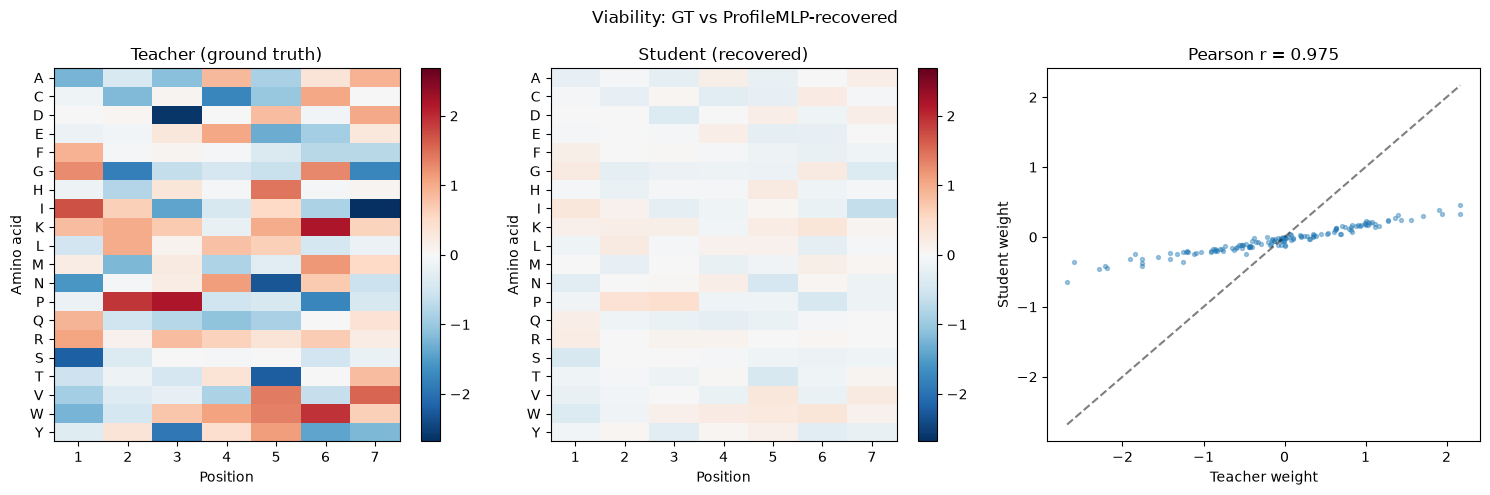

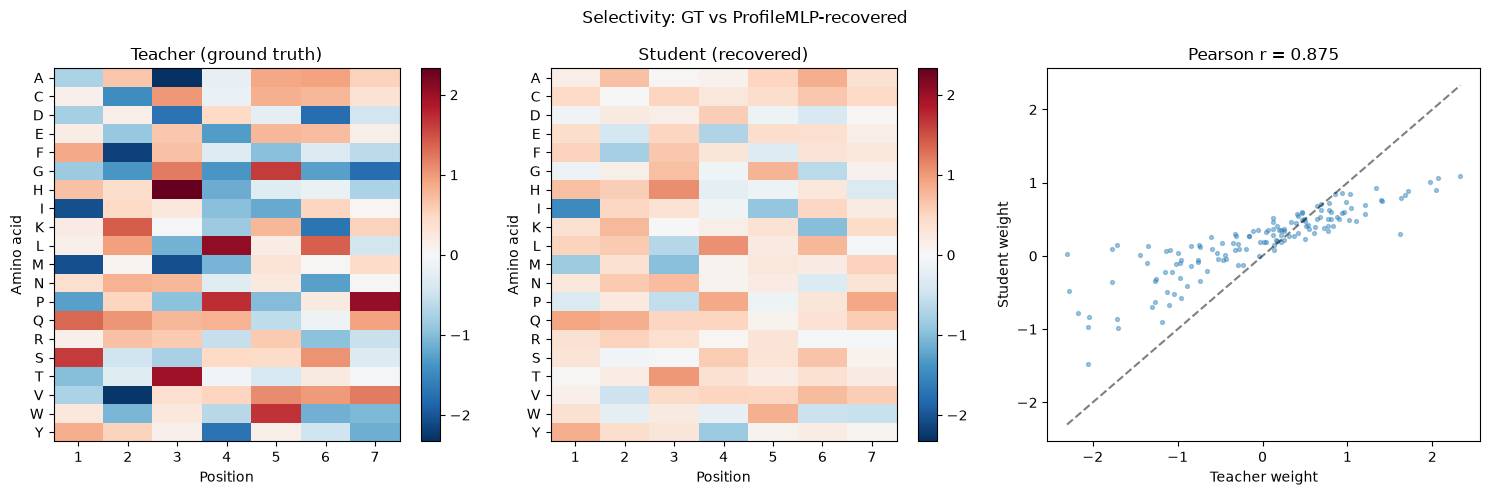

In [ ]:
_ = plot_teacher_vs_student(F_viab, np.array(F_viab_hat), title="Viability: GT vs ProfileMLP-recovered")
_ = plot_teacher_vs_student(F_sel,  np.array(F_sel_hat),  title="Selectivity: GT vs ProfileMLP-recovered")
